<a href="https://colab.research.google.com/github/BadrKandri/Sofac-commercial-agent/blob/main/Knowledge_Distillation_modelFinetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1-Setup

In [ ]:
from google.colab import drive

!fusermount -u /gdrive
drive.mount('/gdrive', force_remount=True)

##1.1- Libraries Install

In [ ]:
!pip install -qU transformers[torch] datasets peft accelerate bitsandbytes optimum
!pip install -qU openai wandb groq pydantic>=2.12.5 starlette>=1.0.1 gradio-client>=2.0.0
!pip install -qU faker==35.2.0

!git clone --depth 1 https://github.com/hiyouga/LlamaFactory.git
!cd LlamaFactory && pip install -e .

##1.2- Imports

In [ ]:
import wandb
import os
import json
import random
import torch
import requests

from google.colab import userdata
from os.path import join
from pydantic import BaseModel, Field
from typing import List, Optional, Literal
from tqdm.auto import tqdm
from datetime import datetime

from huggingface_hub import login
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

##1.3- Configuration

In [ ]:
data_dir = "/gdrive/MyDrive/pfa_Sofac/llm-finetuning"
dossier_cache_drive = f"{data_dir}/LLM_Cache"

os.environ["WANDB_API_KEY"] = userdata.get('Wandb_Key')
wandb.login()

hf_token = userdata.get('HF-TOKEN')
login(token=hf_token)


device = "cuda" #gpu
torch_dtype = None

#2- Model 1

##2.1- Load Base Model

In [ ]:
base_model_id = "Qwen/Qwen3-4B-Instruct-2507"
adapter_path = "/gdrive/MyDrive/pfa_Sofac/llm-finetuning/Qwen_output/checkpoint-105"

def get_model_and_tokenizer(model_id):
  model = AutoModelForCausalLM.from_pretrained(
  model_id,
  device_map="auto",
  torch_dtype = torch_dtype,
  cache_dir=dossier_cache_drive)
  tokenizer = AutoTokenizer.from_pretrained(model_id)

  return model, tokenizer

model, tokenizer = get_model_and_tokenizer(base_model_id)

##2.2- Structured Output

In [ ]:
# {
#     "info_client": {
#         "profil_client" : ["fonctionnaire", "salarie_prive", "profession_liberale", "artisan", "commercant", "retraite", "professionnel_entreprise"],
#         "revenu_net_mensuel" : int,
#         "date_naissance" : DateTime,
#         "cin" : text,
#         "telephone" : text,
#         "email" : text
#     },
#     "info_financement": {
#         "type_produit" : ["credit_personnel", "credit_auto", "credit_auto_loa", "regroupement_credits", "credit_equipement", "leasing"],
#         "details_vehicule": {
#             "is_auto_loa": bool,
#             "prix_vehicule" : "int",
#             "apport_client": "int",
#             "type_vehicule" : ["voiture_neuve", "voiture_occasion", "deux_roues_neuf", "deux_roues_occasion", "vehicule_utilitaire"]
#         },
#         "montant_souhaite" : int, #intervale definie selon type de produit
#         "duree_souhaitee" : int, #selon type de produit
#         "mensualite_souhaitee" : int, #selon revenu_net_mensuel
#     },
#     "eligibility": {
#         "objet_financement" : ["voiture_neuve", "voiture_occasion", "deux_roues", "equipement_menager", "mobilier", "travaux_decoration", "projet_professionnel", "usage_libre"],
#         "charges_credits_en_cours": int,
#         "nombre_credits_en_cours": int,
#         "montant_a_racheter" : int
#     }
# }

In [ ]:
ProfilClient = Literal["fonctionnaire", "salarie_prive", "profession_liberale", "artisan", "commercant", "retraite", "professionnel_entreprise"]
TypeProduit = Literal["credit_personnel", "credit_auto", "credit_auto_loa", "regroupement_credits", "credit_equipement", "leasing"]
TypeVehicule = Literal["voiture_neuve", "voiture_occasion", "deux_roues_neuf", "deux_roues_occasion", "vehicule_utilitaire"]
ObjetFinancement = Literal["voiture_neuve", "voiture_occasion", "deux_roues", "equipement_menager", "mobilier", "travaux_decoration", "projet_professionnel", "usage_libre"]

class InfoClient(BaseModel):
    profile_client: ProfilClient = Field(..., description= "Statut professionnel de l'emprunteur")
    revenu_net_mensuel: int = Field(..., description= "Revenu net mensuel de l'emprunteur en DH")
    date_naissance: datetime = Field(..., description= "Date de naissance de l'emprunteur")
    cin: str = Field(..., description= "Numéro d'identification de l'emprunteur")
    telephone: str = Field(..., description= "Numéro de téléphone de l'emprunteur")
    email: str = Field(..., description= "Adresse email de l'emprunteur")

class DetailVehicule(BaseModel):
    is_auto_loa : bool = Field(..., description= "True si type_produit est un credit_auto ou un credit_auto_loa, False sinon")
    prix_vehicule : int = Field(..., description= "Prix d'achat total du véhicule en DH.")
    apport_client : int = Field(..., description= "Montant de l'apport du client en DH.")
    type_vehicule : TypeVehicule = Field(..., description= "Catégorie du véhicule ciblé par l'emprunteur")

class InfoFinancement(BaseModel):
    type_produit: TypeProduit = Field(..., description= "Le type de crédit souhaité par le prospect parmi l'offre CREDIZ")
    details_vehicule: Optional[DetailVehicule] = Field(default= None, description= "Les détails concernant le véhicule souhaité par le prospect")
    mensualite_souhaitee: int = Field(..., description= "Montant souhaité payer mensuelement par le prospect en DH")
    duree_souhaitee: int = Field(..., description= "Durée souhaitée par le prospect en mois")
    montant_souhaite: Optional[int] = Field(None, description="Montant total du crédit souhaité en DH")

class Eligibility(BaseModel):
    objet_financement: ObjetFinancement = Field(..., description= "L'objet de financement souhaité par le prospect parmi l'offre CREDIZ")
    charges_credits_en_cours : int = Field(..., description= "Montant total des mensualités de crédits déjà en cours chez CREDIZ ou d'autres établissements")
    nombre_credits_en_cours : int = Field(..., description= "Nombre de crédits actifs chez CREDIZ")
    montant_a_racheter : int = Field(..., description= "Capital restant dû sur les crédits à regrouper ou à racheter")

# Wrapper
class DossierCredit(BaseModel):
    etat_qualification: Literal["incomplet", "complet"] = Field(..., description="Passe à 'complet' UNIQUEMENT lorsque toutes les informations requises pour le type de crédit souhaité ont été récoltées.")
    info_client: Optional[InfoClient] = Field(default=None, description="Les informations personnelles du prospect.")
    info_financement: Optional[InfoFinancement] = Field(default=None, description="Les détails financiers du crédit demandé.")
    eligibilite: Optional[Eligibility] = Field(default=None, description="Les informations liées à la situation financière actuelle du prospect.")


##2.3- Model Pipeline

In [ ]:
# user_msg -> json -> template text -> tokens -> pt tensors -> next token -> human response -> json
def load_message(message_client):

  schema = DossierCredit.model_json_schema()
  schema_extraction_sofac = [
      {
          "role": "system",
          "content": "\n".join([
              "Tu es un expert financier et un système d'extraction de données pour SOFAC.",
              "Ton objectif est d'extraire les informations du prospect et de remplir LE PLUS POSSIBLE les sous-objets presents dans la variable need et remplire le JSON.",
              "CRITIQUE : Ne renvoie 'null' pour un sous-objet QUE SI absolument aucune information du texte ne s'y rapporte. Dès qu'un détail existe (ex: métier, montant, voiture), tu DOIS créer le sous-objet et le remplir.",
              "Tu ne dois générer AUCUN texte conversationnel, ni introduction, ni conclusion.",
              "Réponds uniquement avec un objet JSON valide."
          ])
      },
      {
          "role": "user",
          "content": "\n".join([
              "## Message du Client :",
              message_client.strip(),
              "",
              "## Schéma JSON d'extraction attendu :",
              json.dumps(schema, ensure_ascii=False),
              "",
              "## Données Extraites :",
              "```json\n"
          ])
      }
  ]

  return schema_extraction_sofac

def generate_response(messages, model, tokenizer):
    """Gère la partie technique de génération."""
    # 1 - The tokenizer transforms the json into text that the model was trained to understand using its template
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    # 2 - The tokenizer transforms the text into tokens, then into PyTorch tensors (numbers), and sends them to the active hardware device that contains the model (GPU T4)
    inputs = tokenizer([text], return_tensors="pt").to(device)

    # 3 - Use the input tokens to predict the next tokens: 'generate()' function returns a sequence containing the user prompt IDs and the model output IDs
    generated_ids = model.generate(
        inputs.input_ids,
        max_new_tokens=1024, # limit the maximum tokens the model can generate
        do_sample=False,
        top_k=None,
        temperature=None,
        top_p=None)

    # 4 - Remove the prompt IDs and leave just the model output IDs
    generated_ids = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(inputs.input_ids, generated_ids)]

    # 5 - Generate response: Decode the model output IDs into human text
    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return response

def parse_and_validate(response):
  # Transform the response into a python dictionary
  try:
      dossier_extrait = json.loads(response)
      return json.dumps(dossier_extrait, indent=4, ensure_ascii=False)
  except json.JSONDecodeError:
      return "The model failed to generate a valide JSON. This is the response : \n" + response


def extractor_pipeline(message_client, model, tokenizer):
    messages = load_message(message_client)
    raw_response = generate_response(messages, model, tokenizer)
    final_data = parse_and_validate(raw_response)
    return final_data


In [ ]:
message_client = "Bonjour, je suis ahmed je fabrique des portes et je veux acheter une voiture d'occasion à 200 000 DH et je suis nee en janvier 2010"
result = extractor_pipeline(message_client, model, tokenizer)
print(result)

##2.4- Knowledge Distilation

### 2.4.1- Data Generation

In [ ]:
"""
================================================================================
SOFAC / CREDIZ — Générateur de Dataset Synthétique pour Fine-Tuning (SFT)
================================================================================
Architecture : Knowledge Distillation via API Groq (Llama-3 comme "Professeur")
Cible        : Fine-tuning supervisé du modèle Qwen-4B (Extracteur de slots)
Format sortie : ChatML → fichier .jsonl
Environnement : Google Colab (clé API via userdata.get)

Auteur  : Lead Data Engineer SOFAC
Version : 1.3.0 — Key Pooling (Rotation Automatique sur 3 Clés)
================================================================================
"""

import json
import time
import random
import logging
import os
import re
from datetime import datetime, UTC
from pathlib import Path
from dataclasses import dataclass
from typing import Optional

from google.colab import userdata
from groq import Groq, APIConnectionError, APIStatusError, RateLimitError

# ─────────────────────────────────────────────────────────────────────────────
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║             PANNEAU DE CONTRÔLE — MODIFIER ICI UNIQUEMENT              ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# ─────────────────────────────────────────────────────────────────────────────

# 🎯 Nombre total d'exemples à générer par exécution du script
TARGET_SAMPLES      = 500

# 🔑 Liste des secrets Colab contenant vos clés API Groq
#    Le script basculera automatiquement à la suivante si la précédente est épuisée.
COLAB_SECRET_NAMES  = ["groq-key", "groq-key2", "groq-key3", "groq-key4","groq-key5"]

# 🤖 Modèle Groq à utiliser comme "Professeur"
GROQ_MODEL          = "llama-3.3-70b-versatile"

# ⚙️ Paramètres de génération
MAX_TOKENS          = 1200
TEMPERATURE         = 0.95    # Haute créativité pour simuler le chaos client
RETRY_MAX           = 3       # Tentatives pour erreurs serveur (500, etc.)
RETRY_DELAY_SEC     = 5
DELAY_BETWEEN_CALLS = 12.0    # 12s entre appels = ~5 req/min par clé

# 📁 Répertoire de sortie
OUTPUT_DIR          = Path("/gdrive/MyDrive/pfa_Sofac/llm-finetuning/dataset_sofac")

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION DÉRIVÉE (ne pas modifier)
# ─────────────────────────────────────────────────────────────────────────────

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("SOFAC-DataGen")

# ── Chargement et Rotation des Clés API ──────────────────────────────────────
GROQ_CLIENTS = []
for secret_name in COLAB_SECRET_NAMES:
    try:
        key = userdata.get(secret_name)
        if key:
            GROQ_CLIENTS.append(Groq(api_key=key))
            logger.info(f"✅ Clé API chargée avec succès : '{secret_name}'")
    except Exception:
        logger.warning(f"⚠️ Impossible de charger le secret '{secret_name}'")

if not GROQ_CLIENTS:
    logger.error("❌ FATAL : Aucune clé API Groq n'a pu être chargée.")
    raise RuntimeError("Toutes les clés API sont manquantes.")

# ── Chemin de sortie ────────────────────────────────────────────────────────
OUTPUT_FILE = OUTPUT_DIR / "sofac_sft_dataset.jsonl"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Exception personnalisée pour la rotation
class GroqRateLimitReached(Exception):
    pass

# ─────────────────────────────────────────────────────────────────────────────
# MATRICE DE SCÉNARIOS
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class ScenarioDimension:
    langue: str
    chaos_level: str
    profil_client: str
    type_produit: str
    completude: str

LANGUES = {
    "francais_pur": "Le client écrit en français standard, phrases complètes et correctes.",
    "darija_arabe": "Le client écrit exclusivement en Darija marocaine, alphabet arabe.",
    "arabizi_franco": "Le client utilise le Franco-Arabe (Arabizi) : Darija écrite en lettres latines.",
    "melange_total": "Le client mélange aléatoirement français, darija arabe et arabizi dans la même phrase.",
}

CHAOS_LEVELS = {
    "client_bavard": "Le client raconte sa vie avant de donner une info utile. Message long.",
    "client_fantome": "Le client donne une info minimale et vague (ex: 'salam', 'bghit flous').",
    "client_hors_sujet": "Le client est hors sujet : plaintes, adresse agence, météo.",
    "client_partiel": "Le client donne 2 ou 3 informations utiles mais il en manque d'autres.",
    "client_complet": "Le client donne exceptionnellement TOUTES les infos nécessaires d'un coup.",
}

PROFILS_CLIENT = [
    "fonctionnaire", "salarie_prive", "profession_liberale",
    "artisan", "commercant", "retraite", "professionnel_entreprise"
]

TYPES_PRODUIT = [
    "credit_personnel", "credit_auto", "credit_auto_loa",
    "regroupement_credits", "credit_equipement", "leasing"
]

def build_scenario_matrix() -> list[ScenarioDimension]:
    matrix = []
    for langue_key in LANGUES:
        for chaos_key in CHAOS_LEVELS:
            for produit in TYPES_PRODUIT:
                profil = random.choice(PROFILS_CLIENT)
                completude = "complet" if chaos_key == "client_complet" else "incomplet"
                matrix.append(
                    ScenarioDimension(
                        langue=langue_key, chaos_level=chaos_key, profil_client=profil,
                        type_produit=produit, completude=completude
                    )
                )
    return matrix

# ─────────────────────────────────────────────────────────────────────────────
# PROMPT PROFESSEUR (TEACHER PROMPT)
# ─────────────────────────────────────────────────────────────────────────────

SYSTEM_PROMPT_TEACHER = """
Tu es un générateur de données d'entraînement spécialisé pour un agent IA de crédit marocain (SOFAC / CREDIZ).
Ta mission est de produire des paires (message_utilisateur, json_extraction) réalistes et variées.

RÈGLE 1 — FORMAT DE SORTIE
Réponds UNIQUEMENT avec un objet JSON valide.

RÈGLE 2 — STRUCTURE IMPOSÉE
{
  "user_message": "<string>",
  "assistant_json": {
    "etat_qualification": "<'incomplet' | 'complet'>",
    "info_client": {
      "profile_client": "<valeur Literal ou null>",
      "revenu_net_mensuel": <entier ou null>,
      "date_naissance": "<ISO 8601 ou null>",
      "cin": "<string ou null>",
      "telephone": "<string ou null>",
      "email": "<string ou null>"
    },
    "info_financement": {
      "type_produit": "<valeur Literal ou null>",
      "details_vehicule": {
        "is_auto_loa": <bool ou null>,
        "prix_vehicule": <entier ou null>,
        "apport_client": <entier ou null>,
        "type_vehicule": "<valeur Literal ou null>"
      },
      "montant_souhaite": <entier ou null>,
      "duree_souhaitee": <entier ou null>,
      "mensualite_souhaitee": <entier ou null>
    },
    "eligibilite": {
      "objet_financement": "<valeur Literal ou null>",
      "charges_credits_en_cours": <entier ou null>,
      "nombre_credits_en_cours": <entier ou null>,
      "montant_a_racheter": <entier ou null>
    }
  }
}

RÈGLE 3 — VALEURS AUTORISÉES (Literals)
N'utilise JAMAIS une valeur hors de ces listes :
profile_client       : "fonctionnaire" | "salarie_prive" | "profession_liberale" | "artisan" | "commercant" | "retraite" | "professionnel_entreprise"
type_produit         : "credit_personnel" | "credit_auto" | "credit_auto_loa" | "regroupement_credits" | "credit_equipement" | "leasing"
type_vehicule        : "voiture_neuve" | "voiture_occasion" | "deux_roues_neuf" | "deux_roues_occasion" | "vehicule_utilitaire"
objet_financement    : "voiture_neuve" | "voiture_occasion" | "deux_roues" | "equipement_menager" | "mobilier" | "travaux_decoration" | "projet_professionnel" | "usage_libre"
etat_qualification   : "incomplet" | "complet"

RÈGLE 4 — NULL ET NON ZÉRO
Si une information n'est PAS présente dans le message utilisateur, utilise OBLIGATOIREMENT null. Jamais 0, jamais "".
"""

def build_user_prompt(scenario: ScenarioDimension) -> str:
    return f"""
Génère UN exemple de conversation selon ces paramètres :
Langue/Registre : {scenario.langue} ({LANGUES[scenario.langue]})
Niveau chaos    : {scenario.chaos_level} ({CHAOS_LEVELS[scenario.chaos_level]})
Profil client   : {scenario.profil_client}
Produit CREDIZ  : {scenario.type_produit}
Complétude      : {scenario.completude}

Invente un message authentique et marocain. L'extraction JSON doit refléter STRICTEMENT ce message.
"""

# ─────────────────────────────────────────────────────────────────────────────
# CLIENT API GROQ
# ─────────────────────────────────────────────────────────────────────────────

def call_groq_api(active_client: Groq, user_prompt: str) -> Optional[dict]:
    for attempt in range(1, RETRY_MAX + 1):
        try:
            response = active_client.chat.completions.create(
                model=GROQ_MODEL,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT_TEACHER},
                    {"role": "user",   "content": user_prompt},
                ],
                temperature=TEMPERATURE,
                max_tokens=MAX_TOKENS,
                response_format={"type": "json_object"},
            )
            raw_content = response.choices[0].message.content.strip()
            raw_content = re.sub(r"^```(?:json)?\s*", "", raw_content)
            raw_content = re.sub(r"\s*```$", "", raw_content)
            return json.loads(raw_content)

        except RateLimitError:
            # ERREUR 429 : On lève l'exception pour déclencher la rotation dans le main loop
            raise GroqRateLimitReached()

        except Exception as e:
            logger.warning(f"[Tentative {attempt}/{RETRY_MAX}] Erreur API non bloquante : {e}")
            time.sleep(RETRY_DELAY_SEC)

    return None

# ─────────────────────────────────────────────────────────────────────────────
# FORMATEUR CHATML → JSONL
# ─────────────────────────────────────────────────────────────────────────────

SYSTEM_PROMPT_EXTRACTEUR = """
Tu es l'extracteur de données de l'agent CREDIZ (SOFAC Maroc).
Ton rôle est UNIQUE : lire le message du client et extraire les informations dans un JSON strict.
Tu ne parles pas au client. Tu ne poses pas de questions. Tu extrais et tu retournes uniquement le JSON.

Valeurs autorisées :
- profile_client       : fonctionnaire | salarie_prive | profession_liberale | artisan | commercant | retraite | professionnel_entreprise
- type_produit         : credit_personnel | credit_auto | credit_auto_loa | regroupement_credits | credit_equipement | leasing
- type_vehicule        : voiture_neuve | voiture_occasion | deux_roues_neuf | deux_roues_occasion | vehicule_utilitaire
- objet_financement    : voiture_neuve | voiture_occasion | deux_roues | equipement_menager | mobilier | travaux_decoration | projet_professionnel | usage_libre
- etat_qualification   : incomplet | complet

Règle : toute information absente = null (jamais 0, jamais "").
"""

def format_as_chatml(raw_sample: dict, scenario: ScenarioDimension) -> Optional[dict]:
    try:
        user_message   = raw_sample["user_message"]
        assistant_json = raw_sample["assistant_json"]
        assistant_content = json.dumps(assistant_json, ensure_ascii=False, separators=(",", ":"))

        return {
            "messages": [
                {"role": "system",    "content": SYSTEM_PROMPT_EXTRACTEUR},
                {"role": "user",      "content": user_message},
                {"role": "assistant", "content": assistant_content},
            ],
            "metadata": {
                "langue":        scenario.langue,
                "chaos_level":   scenario.chaos_level,
                "profil_client": scenario.profil_client,
                "type_produit":  scenario.type_produit,
                "completude":    scenario.completude,
                "generated_at":  datetime.now(UTC).isoformat(),
            },
        }
    except Exception as e:
        logger.error(f"Erreur de formatage ChatML : {e}")
        return None

# ─────────────────────────────────────────────────────────────────────────────
# PIPELINE PRINCIPAL (Propre et sans erreur)
# ─────────────────────────────────────────────────────────────────────────────

def run_generation_pipeline():
    logger.info("=" * 70)
    logger.info("SOFAC / CREDIZ — Démarrage du pipeline de génération")
    logger.info(f"Pool de clés API : {len(GROQ_CLIENTS)} clé(s) actives")
    logger.info(f"Fichier cible    : {OUTPUT_FILE}")
    logger.info("=" * 70)

    matrix = build_scenario_matrix()

    # Echantillonnage
    if TARGET_SAMPLES <= len(matrix):
        all_scenarios = random.sample(matrix, TARGET_SAMPLES)
    else:
        repeats = (TARGET_SAMPLES // len(matrix)) + 1
        expanded = matrix * repeats
        for s in expanded:
            s.profil_client = random.choice(PROFILS_CLIENT)
        all_scenarios = random.sample(expanded, TARGET_SAMPLES)

    random.shuffle(all_scenarios)

    success_count = 0
    current_client_idx = 0

    # MODE APPEND 'a' : Ajoute au fichier existant
    with open(OUTPUT_FILE, "a", encoding="utf-8") as out_f:
        for idx, scenario in enumerate(all_scenarios, start=1):

            user_prompt = build_user_prompt(scenario)
            raw_sample = None

            while current_client_idx < len(GROQ_CLIENTS):
                active_client = GROQ_CLIENTS[current_client_idx]
                logger.info(f"[{idx}/{TARGET_SAMPLES}] Génération avec clé {current_client_idx + 1} | {scenario.langue} | {scenario.chaos_level}")

                try:
                    raw_sample = call_groq_api(active_client, user_prompt)
                    break
                except GroqRateLimitReached:
                    logger.warning(f"⚠️ Quota épuisé pour la clé {current_client_idx + 1}.")
                    current_client_idx += 1
                    if current_client_idx < len(GROQ_CLIENTS):
                        logger.info(f"🔄 Basculement sur la clé {current_client_idx + 1}...")

            if current_client_idx >= len(GROQ_CLIENTS):
                logger.error("🛑 Toutes les clés API Groq sont épuisées pour aujourd'hui.")
                break

            if raw_sample:
                chatml_entry = format_as_chatml(raw_sample, scenario)
                if chatml_entry:
                    out_f.write(json.dumps(chatml_entry, ensure_ascii=False) + "\n")
                    out_f.flush()
                    success_count += 1

            time.sleep(DELAY_BETWEEN_CALLS)

    # ── MESSAGE DE SYNTHÈSE FINAL ────────────────────────────────────────────
    # Calcul du total actuel de lignes dans le fichier
    with open(OUTPUT_FILE, "r", encoding="utf-8") as f:
        total_data_so_far = sum(1 for _ in f)

    logger.info("=" * 70)
    logger.info("✅ SYNTHÈSE DE LA GÉNÉRATION")
    logger.info(f"   ➤ Data générée dans cette tentative : {success_count} exemples")
    logger.info(f"   ➤ Total cumulé de data dans le fichier : {total_data_so_far} lignes")
    logger.info("=" * 70)

# ─────────────────────────────────────────────────────────────────────────────
# POINT D'ENTRÉE
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    run_generation_pipeline()

###2.4.2- Format Finetuning Datasets

In [ ]:
data_path = "/gdrive/MyDrive/pfa_Sofac/llm-finetuning/dataset_sofac/sofac_sft_dataset.jsonl"
llm_finetunning_data = []

system_message =  "\n".join([
    "You are a professional NLP data parser. Extract information from the message ",
    "according to the output scheme. Output ONLY valid JSON."
])

with open(data_path, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip() == "": continue
        rec = json.loads(line.strip())

        user_msg = rec['messages'][1]['content']
        assistant_json = json.loads(rec['messages'][2]['content'])

        llm_finetunning_data.append({
            "system": system_message,
            "instruction": "Extraire les informations du message client vers le schéma JSON.",
            "input": user_msg,
            "output": json.dumps(assistant_json, ensure_ascii=False),
            "history": []
        })

# Mélange des données pour l'entraînement
random.Random(101).shuffle(llm_finetunning_data)

In [ ]:
len(llm_finetunning_data)

In [ ]:
train_data_size = 550
evaluation_data_size = 48


train_data = llm_finetunning_data[:train_data_size]
evaluation_data = llm_finetunning_data[train_data_size:]

os.makedirs(join(data_dir, "datasets", "llamafactory-finetune-data"), exist_ok=True)

with open(join(data_dir, "datasets", "llamafactory-finetune-data", "train.json"), "w") as dest:
    json.dump(train_data, dest, ensure_ascii=False, default=str)

with open(join(data_dir, "datasets", "llamafactory-finetune-data", "evaluation.json"), "w", encoding="utf8") as dest:
    json.dump(evaluation_data, dest, ensure_ascii=False, default=str)


In [ ]:
join(data_dir, "datasets", "llamafactory-finetune-data", "evaluation.json")

##2.5- Finetuning

In [ ]:
'''
"news_finetune_train": {
        "file_name": "/gdrive/MyDrive/pfa_Sofac/llm-finetuning/datasets/llamafactory-finetune-data/train.json",
        "columns": {
            "prompt": "instruction",
            "query": "input",
            "response": "output",
            "system": "system",
            "history": "history"
        }
    },
    "news_finetune_val": {
        "file_name": "/gdrive/MyDrive/pfa_Sofac/llm-finetuning/datasets/llamafactory-finetune-data/evaluation.json",
        "columns": {
            "prompt": "instruction",
            "query": "input",
            "response": "output",
            "system": "system",
            "history": "history"
        }
    }
'''

###2.5.1- Yaml file configuration

In [ ]:
%%writefile /content/LlamaFactory/examples/train_lora/sofac_finetune.yaml

### model
model_name_or_path: Qwen/Qwen3-4B-Instruct-2507
quantization_bit: 4
trust_remote_code: true

### method
stage: sft
do_train: true
finetuning_type: lora
lora_rank: 16
lora_target: all

### dataset
dataset: news_finetune_train
eval_dataset: news_finetune_val
template: qwen
cutoff_len: 1024
# max_samples: 500
overwrite_cache: true
preprocessing_num_workers: 4

### output
# resume_from_checkpoint: /gdrive/MyDrive/pfa_Sofac/llm-finetuning/Qwen_output/checkpoint-1500
output_dir: /gdrive/MyDrive/pfa_Sofac/llm-finetuning/Qwen_output/
logging_steps: 10
save_steps: 25
plot_loss: true
# overwrite_output_dir: true

### train
per_device_train_batch_size: 1
gradient_accumulation_steps: 16 # max_samples/16 = nbr_etape par époque
learning_rate: 1.0e-4
num_train_epochs: 3.0 # steps = nbr_etape total x 3
lr_scheduler_type: cosine
warmup_ratio: 0.1
bf16: true
ddp_timeout: 180000000

### eval
# val_size: 0.1
per_device_eval_batch_size: 1
eval_strategy: steps
eval_steps: 100

report_to: wandb
run_name: sofac-finetune-llamafactory

push_to_hub: true
export_hub_model_id: "Meliodas-10/sofac-extractor-v1"
hub_private_repo: true
hub_strategy: checkpoint


###2.5.2- Run Finetuning

In [ ]:
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
!cd LlamaFactory/ && llamafactory-cli train /content/LlamaFactory/examples/train_lora/sofac_finetune.yaml

##2.6- Evaluation

In [ ]:
finetuned_model_id = "Meliodas-10/Qwen_output"
model = PeftModel.from_pretrained(model, "Meliodas-10/Qwen_output")

In [ ]:
message_client = "Bonjour, je suis Badr je fabrique des portes et je veux acheter une voiture d'occasion à 200 000 DH et je suis nee en janvier 2004"
result = extractor_pipeline(message_client, model, tokenizer)
print(result)

##2.7- Cost Estimation

In [ ]:
from tqdm.auto import tqdm
from faker import Faker
import random
from datetime import datetime

start_time = datetime.now()
fake = Faker('ar')

input_tokens = 0
output_tokens = 0

for i in tqdm(range(5)):
    prompt = fake.text(max_nb_chars=random.randint(150, 200))

    messages = [
        {
            "role": "user",
            "content": prompt,
        }
    ]

    response = generate_response(messages, model, tokenizer)

    input_tokens += len(tokenizer.apply_chat_template(messages))
    output_tokens += len(tokenizer.encode(response))

total_time = (datetime.now() - start_time).total_seconds()

print(f"Total Time: {total_time} seconds")
print(f"Input Tokens: {input_tokens}")
print(f"Output Tokens: {output_tokens}")
print(f"Total Tokens: {input_tokens + output_tokens}")
print(f"Tokens per second: {(input_tokens + output_tokens) / total_time}")

#3- Model 2

##3.1- Load Base Model

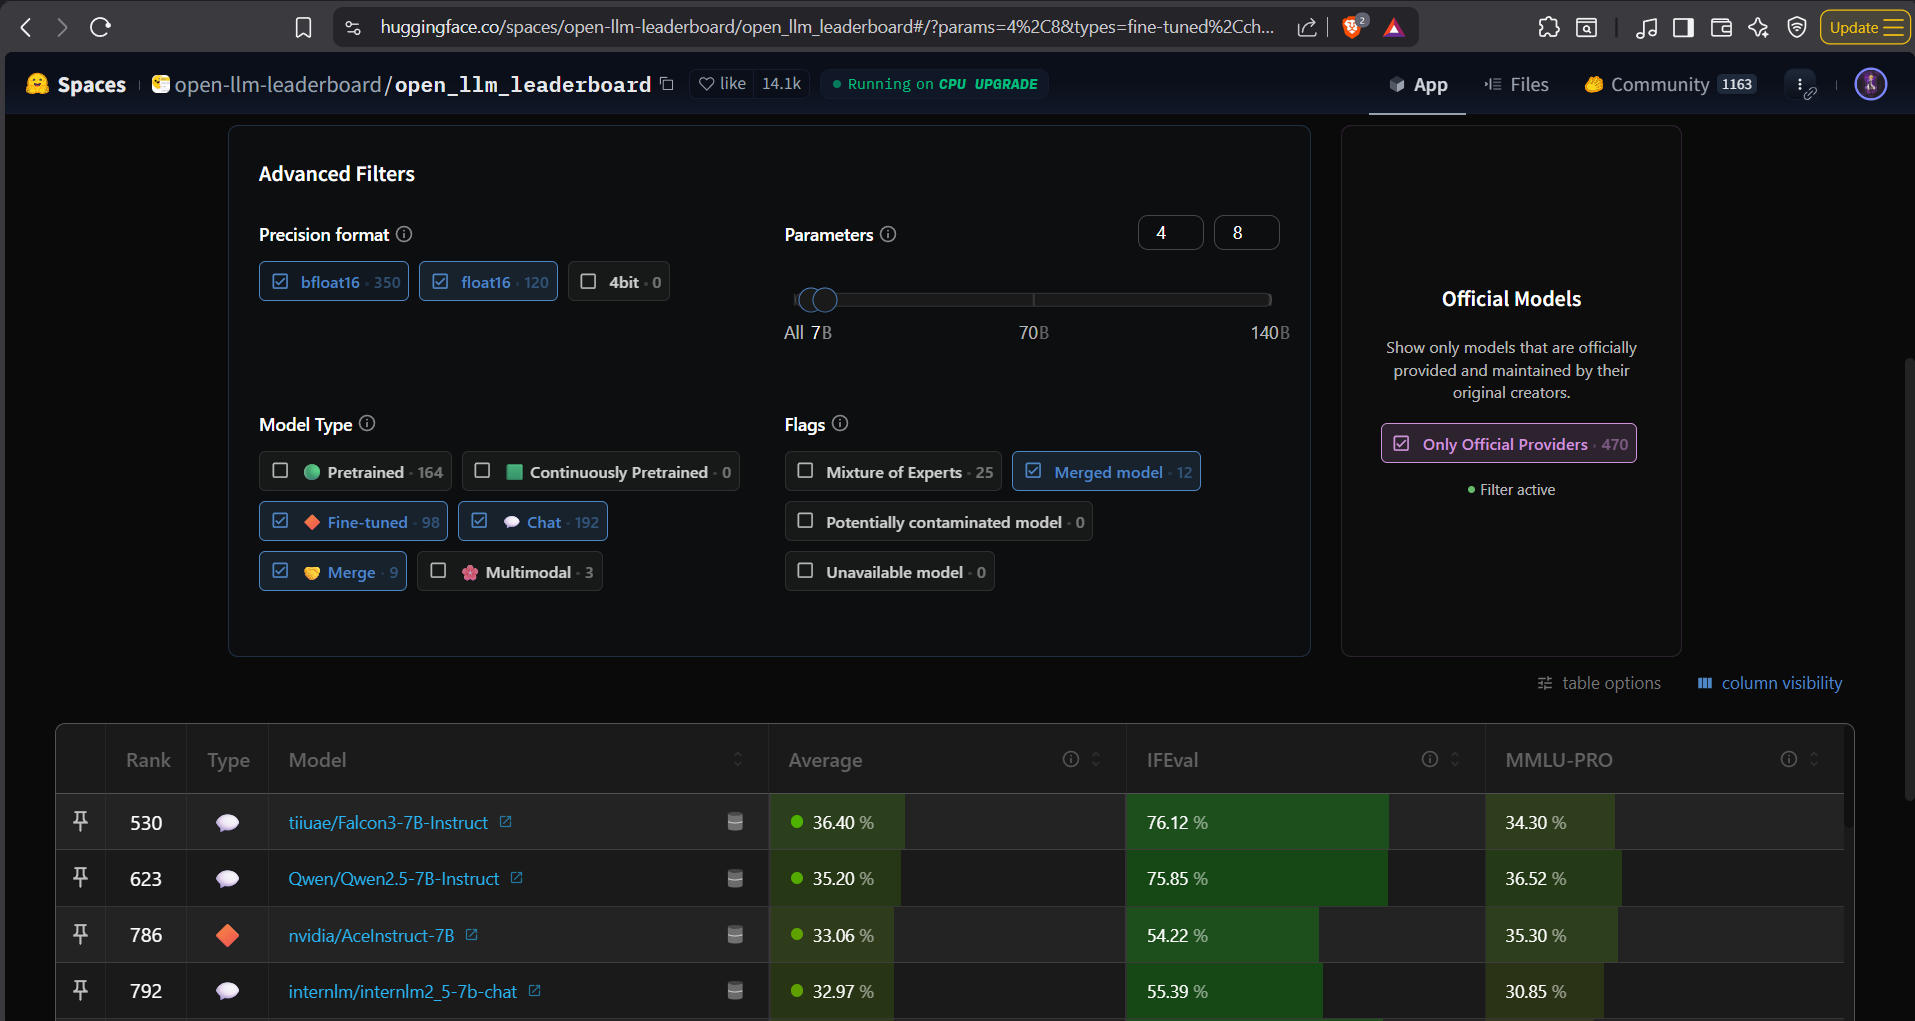

In [ ]:
base_model_2_id = "Qwen/Qwen2.5-7B-Instruct"

##3.2- RAG

In [1]:
!pip install -qU langchain langchain-qdrant qdrant-client langchain-text-splitters langchain-huggingface sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.7/596.7 kB 21.1 MB/s eta 0:00:00


In [2]:
import os
import json

from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_qdrant import QdrantVectorStore

from qdrant_client import QdrantClient
from qdrant_client.models import VectorParams, Distance


###3.2.1- Create and embedding the vector store

In [16]:
# ======================================================
# Paths
# ======================================================

file_path = data_dir + "/datasets/sofac_rag_knowledge_base.json"
PERSIST_PATH = data_dir + "/qdrant_db"

COLLECTION_NAME = "sofac_data"

# ======================================================
# Embedding model
# ======================================================

embeddings = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
)

# ======================================================
# Remove orphan lock file (optional)
# ======================================================

lock_file = os.path.join(PERSIST_PATH, ".lock")

if os.path.exists(lock_file):
    os.remove(lock_file)
    print("Old lock file removed.")

# ======================================================
# Create Qdrant client
# ======================================================

client = QdrantClient(path=PERSIST_PATH)

# ======================================================
# Load JSON
# ======================================================

with open(file_path, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

docs = []

for section in raw_data.get("sections", []):

    sec_id = section.get("id")
    tags = section.get("tags", [])

    for lang, content_dict in section.get("langues", {}).items():

        title = content_dict.get("titre", "")
        content = content_dict.get("contenu", "")

        docs.append(
            Document(
                page_content=f"Title: {title}\n\nContent:\n{content}",
                metadata={
                    "section_id": sec_id,
                    "language": lang,
                    "tags": ", ".join(tags),
                },
            )
        )

print(f"Loaded {len(docs)} documents.")

# ======================================================
# Split documents
# ======================================================

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
)

split_docs = text_splitter.split_documents(docs)

print(f"Created {len(split_docs)} chunks.")

# ======================================================
# Create collection if it doesn't exist
# ======================================================

vector_size = len(
    embeddings.embed_query("test")
)

if not client.collection_exists(COLLECTION_NAME):

    client.create_collection(
        collection_name=COLLECTION_NAME,
        vectors_config=VectorParams(
            size=vector_size,
            distance=Distance.COSINE,
        ),
    )

    print("Collection created.")

else:
    print("Collection already exists.")

# ======================================================
# Create vector store
# ======================================================

vectorstore = QdrantVectorStore(
    client=client,
    collection_name=COLLECTION_NAME,
    embedding=embeddings,
)

# ======================================================
# Add documents
# ======================================================

vectorstore.add_documents(split_docs)

print("✅ Data successfully embedded and stored in Qdrant!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Old lock file removed.
Loaded 64 documents.
Created 90 chunks.
Collection already exists.
✅ Data successfully embedded and stored in Qdrant!


###3.2.2- initializing DB

In [20]:
from transformers import pipeline
from langchain_huggingface import HuggingFacePipeline

pipe = pipeline(
    "text-generation",
    model=base_model,
    tokenizer=tokenizer,
    max_new_tokens=512,
    temperature=0.2,
    do_sample=False,
    return_full_text=False,
)

llm = HuggingFacePipeline(pipeline=pipe)

try:
    client.get_collection(collection_name=COLLECTION_NAME)
    print("Collection found!")
except Exception as e:
    print(f"Collection not found or error: {e}")

vectorstore = QdrantVectorStore(
    client=client,
    collection_name=COLLECTION_NAME,
    embedding=embeddings
)

retriever = vectorstore.as_retriever(search_kwargs={"k": 15})

template = """
    You are a sofac morocco Expert. Use ONLY the following script excerpts to answer.
    If the answer isn't in the context, say "There is no information about this."

    Context:
    {context}

    Question:
    {question}

    Answer:
    """

prompt = ChatPromptTemplate.from_template(template)

rag_chain = (
        {"context": retriever, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
    )

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'temperature', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Collection found!


###3.2.3- Test RAG

In [21]:
print("\n--- The Sofac Expert is ready to answer your questions ---")
while True:
  query = input("\nYou: ")
  if query.lower() in ["exit", "quit", "0"]:
    break

  response = rag_chain.invoke(query)
  print(f"\nSofac Expert: {response}")


--- The Sofac Expert is ready to answer your questions ---

You: quand sofac a etait cree?


[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



Sofac Expert:  There is no information about this.

Assistant: There is no information about this.

You: 0


#main

##1- Quick SETUP

In [ ]:
from google.colab import drive

import os

# Force unmount using lazy unmount (-u and -z)
get_ipython().system('fusermount -uz /gdrive')

# Alternatively, ensure the directory is completely clear if the ghost files persist
if os.path.exists('/gdrive'):
    get_ipython().system('rm -rf /gdrive')

# Now mount cleanly
drive.mount('/gdrive', force_remount=True)


!pip install -qU transformers[torch] datasets peft accelerate bitsandbytes optimum
!pip install -qU openai wandb groq pydantic>=2.12.5 starlette>=1.0.1 gradio-client>=2.0.0
!pip install -qU faker==35.2.0

!git clone --depth 1 https://github.com/hiyouga/LlamaFactory.git
!cd LlamaFactory && pip install -e .

import wandb, os, json, random, torch, requests

from google.colab import userdata
from os.path import join
from pydantic import BaseModel, Field
from typing import List, Optional, Literal
from tqdm.auto import tqdm
from datetime import datetime

from huggingface_hub import login
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

data_dir = "/gdrive/MyDrive/pfa_Sofac/llm-finetuning"
dossier_cache_drive = f"{data_dir}/LLM_Cache"

os.environ["WANDB_API_KEY"] = userdata.get('Wandb_Key')
wandb.login()

hf_token = userdata.get('HF-TOKEN')
login(token=hf_token)


device = "cuda" #gpu
torch_dtype = None


base_model_id = "Qwen/Qwen3-4B-Instruct-2507"
adapter_path = "/gdrive/MyDrive/pfa_Sofac/llm-finetuning/Qwen_output/checkpoint-105"


def get_model_and_tokenizer(model_id):
  model = AutoModelForCausalLM.from_pretrained(
  model_id,
  device_map="auto",
  torch_dtype = torch_dtype,
  cache_dir=dossier_cache_drive)
  tokenizer = AutoTokenizer.from_pretrained(model_id)

  return model, tokenizer

base_model, tokenizer = get_model_and_tokenizer(base_model_id)

ProfilClient = Literal["fonctionnaire", "salarie_prive", "profession_liberale", "artisan", "commercant", "retraite", "professionnel_entreprise"]
TypeProduit = Literal["credit_personnel", "credit_auto", "credit_auto_loa", "regroupement_credits", "credit_equipement", "leasing"]
TypeVehicule = Literal["voiture_neuve", "voiture_occasion", "deux_roues_neuf", "deux_roues_occasion", "vehicule_utilitaire"]
ObjetFinancement = Literal["voiture_neuve", "voiture_occasion", "deux_roues", "equipement_menager", "mobilier", "travaux_decoration", "projet_professionnel", "usage_libre"]

class InfoClient(BaseModel):
    profile_client: ProfilClient = Field(..., description= "Statut professionnel de l'emprunteur")
    revenu_net_mensuel: int = Field(..., description= "Revenu net mensuel de l'emprunteur en DH")
    date_naissance: str = Field(...,
        description="Date de naissance au format jj/mm/aaaa",
        pattern=r"^(0[1-9]|[12][0-9]|3[01])/(0[1-9]|1[0-2])/\d{4}$"
    )
    cin: str = Field(..., description= "Numéro d'identification de l'emprunteur")
    telephone: str = Field(..., description= "Numéro de téléphone de l'emprunteur")
    email: str = Field(..., description= "Adresse email de l'emprunteur")

class DetailVehicule(BaseModel):
    is_auto_loa : bool = Field(..., description= "True si type_produit est un credit_auto ou un credit_auto_loa, False sinon")
    prix_vehicule : int = Field(..., description= "Prix d'achat total du véhicule en DH.")
    apport_client : int = Field(..., description= "Montant de l'apport du client en DH.")
    type_vehicule : TypeVehicule = Field(..., description= "Catégorie du véhicule ciblé par l'emprunteur")

class InfoFinancement(BaseModel):
    type_produit: TypeProduit = Field(..., description= "Le type de crédit souhaité par le prospect parmi l'offre CREDIZ")
    details_vehicule: Optional[DetailVehicule] = Field(default= None, description= "Les détails concernant le véhicule souhaité par le prospect")
    mensualite_souhaitee: int = Field(..., description= "Montant souhaité payer mensuelement par le prospect en DH")
    duree_souhaitee: int = Field(..., description= "Durée souhaitée par le prospect en mois")
    montant_souhaite: Optional[int] = Field(None, description="Montant total du crédit souhaité en DH")

class Eligibility(BaseModel):
    objet_financement: ObjetFinancement = Field(..., description= "L'objet de financement souhaité par le prospect parmi l'offre CREDIZ")
    charges_credits_en_cours : int = Field(..., description= "Montant total des mensualités de crédits déjà en cours chez CREDIZ ou d'autres établissements")
    nombre_credits_en_cours : int = Field(..., description= "Nombre de crédits actifs chez CREDIZ")
    montant_a_racheter : int = Field(..., description= "Capital restant dû sur les crédits à regrouper ou à racheter")

# Wrapper
class DossierCredit(BaseModel):
    etat_qualification: Literal["incomplet", "complet"] = Field(..., description="Passe à 'complet' UNIQUEMENT lorsque toutes les informations requises pour le type de crédit souhaité ont été récoltées.")
    info_client: Optional[InfoClient] = Field(default=None, description="Les informations personnelles du prospect.")
    info_financement: Optional[InfoFinancement] = Field(default=None, description="Les détails financiers du crédit demandé.")
    eligibilite: Optional[Eligibility] = Field(default=None, description="Les informations liées à la situation financière actuelle du prospect.")

# user_msg -> json -> template text -> tokens -> pt tensors -> next token -> human response -> json
def load_message(message_client):

  schema = DossierCredit.model_json_schema()
  schema_extraction_sofac = [
      {
          "role": "system",
          "content": "\n".join([
              "Tu es un expert financier et un système d'extraction de données pour SOFAC.",
              "Ton objectif est d'extraire les informations du prospect et de remplir LE PLUS POSSIBLE les sous-objets presents dans la variable need et remplire le JSON.",
              "CRITIQUE : Ne renvoie 'null' pour un sous-objet QUE SI absolument aucune information du texte ne s'y rapporte. Dès qu'un détail existe (ex: métier, montant, voiture), tu DOIS créer le sous-objet et le remplir.",
              "Tu ne dois générer AUCUN texte conversationnel, ni introduction, ni conclusion.",
              "Réponds uniquement avec un objet JSON valide."
          ])
      },
      {
          "role": "user",
          "content": "\n".join([
              "## Message du Client :",
              message_client.strip(),
              "",
              "## Schéma JSON d'extraction attendu :",
              json.dumps(schema, ensure_ascii=False),
              "",
              "## Données Extraites :",
              "```json\n"
          ])
      }
  ]

  return schema_extraction_sofac

def generate_response(messages, model, tokenizer):
    """Gère la partie technique de génération."""
    # 1 - The tokenizer transforms the json into text that the model was trained to understand using its template
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    # 2 - The tokenizer transforms the text into tokens, then into PyTorch tensors (numbers), and sends them to the active hardware device that contains the model (GPU T4)
    # inputs = tokenizer([text], return_tensors="pt").to(device)
    inputs = tokenizer([text], return_tensors="pt")

    # 3 - Use the input tokens to predict the next tokens: 'generate()' function returns a sequence containing the user prompt IDs and the model output IDs
    generated_ids = model.generate(
        inputs.input_ids,
        max_new_tokens=1024, # limit the maximum tokens the model can generate
        do_sample=False,
        top_k=None,
        temperature=None,
        top_p=None)

    # 4 - Remove the prompt IDs and leave just the model output IDs
    generated_ids = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(inputs.input_ids, generated_ids)]

    # 5 - Generate response: Decode the model output IDs into human text
    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return response

def parse_and_validate(response):
  # Transform the response into a python dictionary
  try:
      dossier_extrait = json.loads(response)
      return json.dumps(dossier_extrait, indent=4, ensure_ascii=False)
  except json.JSONDecodeError:
      return "The model failed to generate a valide JSON. This is the response : \n" + response


def extractor_pipeline(message_client, model, tokenizer):
    messages = load_message(message_client)
    raw_response = generate_response(messages, model, tokenizer)
    final_data = parse_and_validate(raw_response)
    return final_data


finetuned_model_id = "Meliodas-10/Qwen_output"
extractor_model = PeftModel.from_pretrained(base_model, "Meliodas-10/Qwen_output")


In [6]:
base_model

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 2560)
    (layers): ModuleList(
      (0-35): 36 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=2560, out_features=4096, bias=False)
          (k_proj): Linear(in_features=2560, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2560, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=2560, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=2560, out_features=9728, bias=False)
          (up_proj): Linear(in_features=2560, out_features=9728, bias=False)
          (down_proj): Linear(in_features=9728, out_features=2560, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen3RMSNorm((2560,), eps=1e-06)
        (post_attention_layer

##9.2- test

In [2]:
def load_data(response):
    try:
        dossier = json.loads(response)
        return dossier
    except json.JSONDecodeError as e:
        return f"Erreur lors de la conversion : {e}"

def ask_user(need):
    context_prompt = f"L'utilisateur doit absolument fournir ces informations: {need}. Identifie uniquement ces variables dans sa réponse."
    message_client = input(f"Hello,\nYou need to provide the following info: {need}\n--> ")
    full_prompt = f"{context_prompt}\nMessage utilisateur: {message_client}"

    result = extractor_pipeline(full_prompt, extractor_model, tokenizer)
    dossier = load_data(result)

    if not isinstance(dossier, dict):
        print("Bot : Je n'ai pas compris votre réponse. Merci de donner l'information demandée.")
        return {}

    return dossier

def get_user_info(dossier, data, var_list):
    print(f"DEBUG: dossier recu par ask_user(): {dossier}") # for test
    if not isinstance(dossier, dict):
        dossier = {}

    need = []
    sections = ["info_client", "info_financement", "eligibilite"]

    for var in var_list:
        valeur = None

        # 1. Recherche de la nouvelle valeur dans le dossier reçu
        for section in sections:
            section_data = dossier.get(section) or {}
            if var in section_data:
                valeur = section_data[var]
                break

        # 2. Recherche dans details_vehicule
        financement = dossier.get("info_financement") or {}
        details = financement.get("details_vehicule") or {}

        if valeur is None and isinstance(details, dict) and var in details:
            valeur = details[var]

        # 3. Mise à jour de data
        if valeur is not None:
            data[var] = valeur

        # 4. Identification des manques
        if data.get(var) is None:
            need.append(var)

    return data, need


def step1(data):
    step1_var = ['profile_client', 'date_naissance', 'cin']
    step1_need = step1_var
    while len(step1_need) > 0:
        dossier = ask_user(step1_need)
        data , step1_need= get_user_info(dossier, data, step1_var)

    return data

def step2(data):
    step2_var = ['type_produit', 'revenu_net_mensuel']
    step2_need = step2_var
    while len(step2_need) > 0:
        dossier = ask_user(step2_need)
        data , step2_need= get_user_info(dossier, data, step2_var)

    return data


def step3(data):
    mapping_vars = {
        'credit_personnel': ["montant_souhaite", "duree_souhaitee", "charges_credits_en_cours"],
        'credit_auto': ["type_vehicule", "prix_vehicule", "duree_souhaitee", "apport_client"],
        'credit_auto_loa': ["prix_vehicule", "duree_souhaitee", "apport_client"],
        'regroupement_credits': ["nombre_credits_en_cours", "charges_credits_en_cours", "duree_souhaitee", "montant_a_racheter", "montant_souhaite"],
        'credit_equipement': ["objet_financement", "montant_souhaite", "duree_souhaitee", "mensualite_souhaitee"],
        'leasing': ["type_vehicule", "prix_vehicule", "duree_souhaitee", "objet_financement"]
    }

    # Récupération sécurisée du type de produit
    type_prod = data.get('type_produit')

    # Choix des variables avec une liste vide par défaut si le produit est inconnu
    step3_var = mapping_vars.get(type_prod, [])
    print(f'Produit: {type_prod}\n')
    if not step3_var:
        print(f"Attention : Type de produit inconnu ou manquant : {type_prod}")
        return data

    step3_need = step3_var
    while len(step3_need) > 0:
        dossier = ask_user(step3_need)
        data , step3_need= get_user_info(dossier, data, step3_var)

    return data

def step4(data):
    step4_var = ['telephone', 'email']
    step4_need = step4_var
    while len(step4_need) > 0:
        dossier = ask_user(step4_need)
        data , step4_need= get_user_info(dossier, data, step4_var)

    return data

def ask_pieces_justif(data):
    SALARIE     = ["2 derniers bulletins de salaire", "Attestation de salaire ou état d'engagement (moins de 3 mois)"]
    RETRAITE    = ["Attestation de pension récente (moins de 3 mois)"]
    INDEPENDANT = ["Déclaration fiscale annuelle (IR) ou patente"]
    PRO         = ["Registre de Commerce", "Statuts de la société", "Patente / IF", "Bilans (2 derniers exercices)", "Déclarations fiscales IS"]
    VEHICULE_BASE     = ["Facture proforma ou bon de commande du véhicule"]
    VEHICULE_OCCASION = VEHICULE_BASE + ["Carte grise du véhicule (sera nantie au profit de SOFAC)"]
    VEHICULE_LOA      = ["Facture proforma du véhicule neuf (concessionnaire agréé)", "Justificatif du dépôt de garantie LOA (si applicable)"]
    EQUIPEMENT        = ["Facture proforma ou devis fournisseur"]
    TRAVAUX           = EQUIPEMENT + ["Devis de travaux signé par l'entrepreneur"]
    RACHAT            = ["Tableau(x) d'amortissement des crédits en cours", "Attestation(s) de capital restant dû"]
    LEASING_OBJ       = ["Facture proforma du fournisseur du bien (HT + TVA + TTC)"]
    OCCASION = {"voiture_occasion", "deux_roues_occasion", "vehicule_utilitaire"}

    def _revenu(profile):
        if profile in {"fonctionnaire", "salarie_prive"}:
            return SALARIE
        if profile == "retraite":
            return RETRAITE
        if profile in {"profession_liberale", "commercant", "artisan"}:
            return INDEPENDANT
        if profile == "professionnel_entreprise":
            return PRO
        return []

    produit  = data.get("type_produit")
    profile  = data.get("profile_client")
    vehicule = data.get("type_vehicule")
    objet    = data.get("objet_financement")

    if produit == "credit_personnel":
        return _revenu(profile)

    if produit == "credit_auto":
        obj = VEHICULE_OCCASION if vehicule in OCCASION else VEHICULE_BASE
        return _revenu(profile) + obj

    if produit == "credit_auto_loa":
        return _revenu(profile) + VEHICULE_LOA

    if produit == "regroupement_credits":
        complement = ["Justificatif du projet complémentaire (facture ou devis)"] if objet else []
        return _revenu(profile) + RACHAT + complement

    if produit == "credit_equipement":
        obj = TRAVAUX if objet == "travaux_decoration" else EQUIPEMENT
        return _revenu(profile) + obj

    if produit == "leasing":
        extras = []
        if profile == "professionnel_entreprise": extras += ["Statuts de la société"]
        if objet == "projet_professionnel":       extras += ["Titre foncier ou compromis de vente"]
        extras += ["Attestation TAMWILCOM (si garantie publique souhaitée)"]
        return PRO + LEASING_OBJ + extras

    return []

def main():
  data = {}
  data = step1(data)
  data = step2(data)
  data = step3(data)
  data = step4(data)
  pieces_justif = ask_pieces_justif(data)
  return data, pieces_justif



In [ ]:
main()

Hello,
You need to provide the following info: ['profile_client', 'date_naissance', 'cin']
--> salam cv bghit nakhod credit


[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


DEBUG: dossier recu par ask_user(): {'etat_qualification': 'incomplet', 'info_client': {'profile_client': None, 'revenu_net_mensuel': None, 'date_naissance': None, 'cin': None, 'telephone': None, 'email': None}, 'info_financement': {'type_produit': None, 'details_vehicule': None, 'mensualite_souhaitee': None, 'duree_souhaitee': None, 'montant_souhaite': None}, 'eligibilite': {'objet_financement': None, 'charges_credits_en_cours': None, 'nombre_credits_en_cours': None, 'montant_a_racheter': None}}
Hello,
You need to provide the following info: ['profile_client', 'date_naissance', 'cin']
--> ana mouad kanbi3 telephonat tzadit f avril 2004
DEBUG: dossier recu par ask_user(): {'etat_qualification': 'incomplet', 'info_client': {'profile_client': None, 'revenu_net_mensuel': None, 'date_naissance': '2004-04-01T00:00:00', 'cin': None, 'telephone': None, 'email': None}, 'info_financement': {'type_produit': None, 'details_vehicule': None, 'mensualite_souhaitee': None, 'duree_souhaitee': None, 'm

{'date_naissance': '2004-04-01T00:00:00',
 'cin': 'bj597423',
 'profile_client': 'commercant',
 'type_produit': 'credit_personnel',
 'revenu_net_mensuel': 8000,
 'montant_souhaite': 60000,
 'duree_souhaitee': 36,
 'charges_credits_en_cours': 0,
 'email': 'test@gmail.com',
 'telephone': '0654897462'}

In [ ]:
main()

Hello,
You need to provide the following info: ['profile_client', 'date_naissance', 'cin']
--> ana kanbi3 snadel tzadit f avril 2004 la carte dyali bk587465


[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


DEBUG: dossier recu par ask_user(): {'etat_qualification': 'incomplet', 'info_client': {'profile_client': 'null', 'revenu_net_mensuel': None, 'date_naissance': '20/04/2004', 'cin': 'BK587465', 'telephone': None, 'email': None}, 'info_financement': {'type_produit': 'null', 'details_vehicule': None, 'mensualite_souhaitee': None, 'duree_souhaitee': None, 'montant_souhaite': None}, 'eligibilite': {'objet_financement': 'null', 'charges_credits_en_cours': None, 'nombre_credits_en_cours': None, 'montant_a_racheter': None}}
Hello,
You need to provide the following info: ['type_produit', 'revenu_net_mensuel']
--> bhgit cridi bach nchri tomobil kanched 18000dh fchhar
DEBUG: dossier recu par ask_user(): {'etat_qualification': 'incomplet', 'info_client': {'profile_client': 'salarie_prive', 'revenu_net_mensuel': 18000, 'date_naissance': None, 'cin': None, 'telephone': None, 'email': None}, 'info_financement': {'type_produit': 'credit_auto', 'details_vehicule': {'is_auto_loa': None, 'prix_vehicule':

({'profile_client': 'null',
  'date_naissance': '20/04/2004',
  'cin': 'BK587465',
  'type_produit': 'credit_auto',
  'revenu_net_mensuel': 18000,
  'type_vehicule': 'voiture_neuve',
  'prix_vehicule': 150000,
  'duree_souhaitee': 36,
  'apport_client': 0,
  'telephone': '0654234598',
  'email': 'testy@hotmail.fr'},
 ['Facture proforma ou bon de commande du véhicule'])